# Fraud Detection using Machine Learning
## Objective
To build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, addressing class imbalance as a core challenge.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

## Loading the Dataset
In this step, we load the credit card fraud detection dataset into a pandas DataFrame to inspect its structure and prepare it for further analysis.

In [36]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview
In this section, we examine the size of the dataset, data types of each column, and summary statistics.

In [37]:
df.shape

(284807, 31)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [39]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [40]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(1081)

## Removing Duplicate Records
Duplicate records can introduce bias into a machine learning model by giving repeated importance to the same observations. Therefore, duplicate rows are identified and removed to improve data quality before model training.

In [42]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [43]:
df.shape

(283726, 31)

Duplicate records were successfully removed from the dataset. As a result, the total number of rows decreased while the number of columns remained unchanged. This ensures that the dataset contains only unique transactions, improving data quality for machine learning.

## Class Imbalance Analysis
Before training a machine learning model, it is essential to examine the distribution of the target variable (`Class`). Fraud detection datasets are typically highly imbalanced because fraudulent transactions are much rarer than legitimate ones. Understanding this imbalance helps in selecting appropriate evaluation metrics and data balancing techniques.

In [44]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [45]:
df['Class'].value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

### Observation: 
The dataset is highly imbalanced. After removing duplicate records, 99.8333% of the transactions are legitimate, while only 0.1667% are fraudulent. Such an uneven distribution can bias machine learning models toward predicting the majority class. Therefore, appropriate imbalance-handling techniques and evaluation metrics are required to build an effective fraud detection model.

## Transaction Amount Analysis
The `Amount` feature represents the monetary value of each transaction. Analyzing its distribution for both fraudulent and legitimate transactions helps identify patterns and differences between the two classes. Such insights can be useful for understanding fraud behavior and improving model performance.

In [46]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


## Observation:
- The descriptive statistics show noticeable differences between legitimate and fraudulent transaction amounts.
- Although the average fraudulent transaction amount (123.87) is higher than the average legitimate transaction amount (88.41).
- The median fraud amount (9.82) is lower than the median legitimate amount (22.00).
- This indicates that many fraudulent transactions involve relatively small amounts, while a few larger frauds increase the overall average. 
- Additionally, legitimate transactions have a much higher maximum amount than fraudulent ones, suggesting that transaction amount alone is insufficient for accurately identifying fraudulent activity.

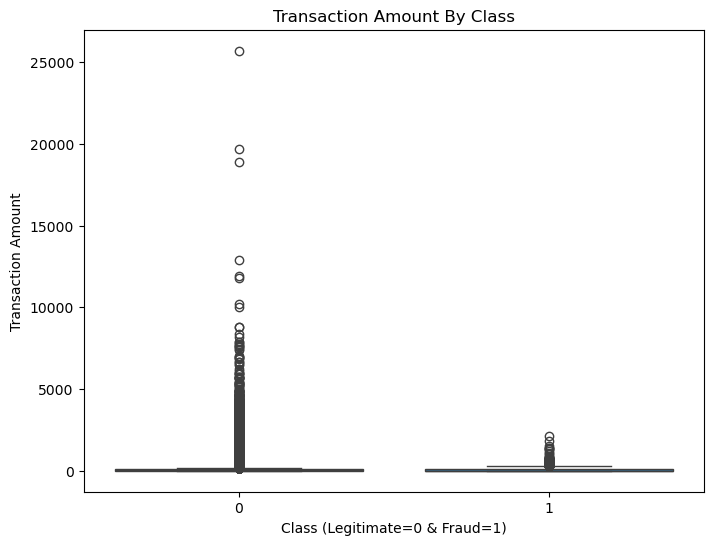

In [47]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Class",y="Amount",data=df)
plt.title("Transaction Amount By Class")
plt.xlabel("Class (Legitimate=0 & Fraud=1)")
plt.ylabel("Transaction Amount")
plt.show()

### Observation
The boxplot shows that most transactions in both classes have relatively small amounts. Both legitimate and fraudulent transactions contain several high-value outliers, but legitimate transactions exhibit much larger maximum values. Since the distributions overlap considerably, transaction amount alone is not sufficient to distinguish fraudulent transactions, highlighting the importance of combining multiple features in the fraud detection model.

## Distribution of Transaction Amounts
A histogram is used to visualize how transaction amounts are distributed for legitimate and fraudulent transactions. This helps identify common transaction ranges, skewness, and differences in spending patterns between the two classes.

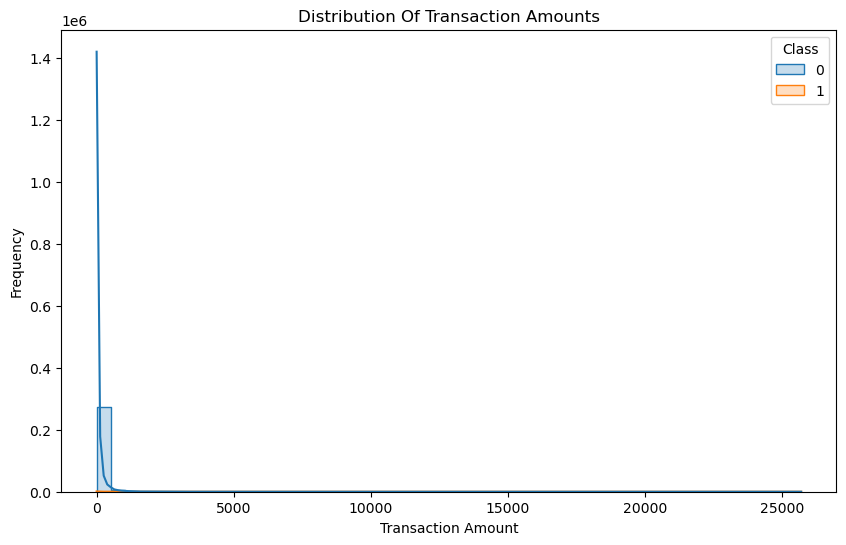

In [48]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    kde=True,
    bins=50,
    element="step")
plt.title("Distribution Of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()
    

### Observation
The histogram shows that transaction amounts are heavily concentrated at lower values, with a long right tail indicating a positively skewed distribution. Only a small number of transactions involve high amounts. Due to the severe class imbalance, the fraud distribution is barely visible when plotted alongside legitimate transactions. These observations suggest that transaction amount alone is not a strong discriminator for fraudulent activity.

In [49]:
df['Hours']=(df['Time']//3600)%24
df[['Time','Hours']].head()

,Time,Hours
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,1.0,0.0
4,2.0,0.0


### Observation
The `Time` feature stores the number of seconds elapsed since the first transaction rather than the actual clock time. To perform time-based analysis, a new `Hours` feature was created by converting elapsed seconds into a 24-hour format. This transformation enables the analysis of transaction patterns across different hours of the day.

## Time-of-Day Analysis
To examine whether transaction activity varies throughout the day, the elapsed time is converted into hours (0–23). This allows us to compare the hourly distribution of legitimate and fraudulent transactions.

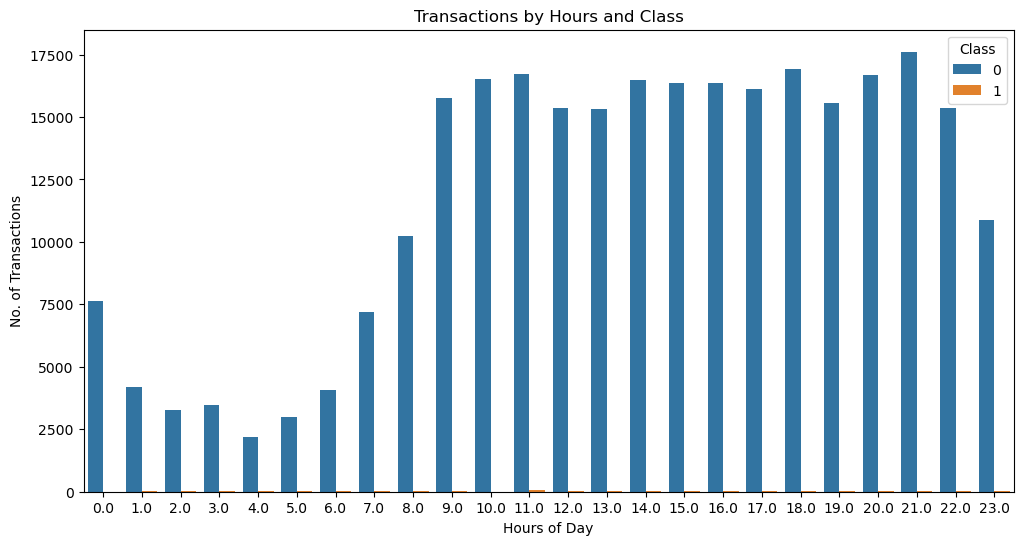

In [50]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='Hours',
    hue='Class')
plt.title("Transactions by Hours and Class")
plt.xlabel("Hours of Day")
plt.ylabel("No. of Transactions")
plt.xticks(range(24))
plt.show()

### Observation
The hourly transaction analysis shows that transaction volume varies throughout the day, with higher activity observed during daytime and evening hours. Fraudulent transactions are present across multiple hours but remain significantly fewer than legitimate transactions due to the highly imbalanced nature of the dataset. The analysis indicates that while transaction timing provides useful contextual information, it is not sufficient by itself to distinguish fraudulent transactions.

## Why Accuracy is a Misleading Metric
Accuracy is one of the most commonly used evaluation metrics in machine learning. It measures the proportion of correctly classified instances out of the total number of predictions made by the model.
**Accuracy Formula:**
Accuracy = (Number of Correct Predictions) / (Total Number of Predictions)
Although accuracy is useful for balanced datasets, it can be highly misleading when working with **imbalanced datasets**, such as credit card fraud detection.
In this dataset, approximately **99.83%** of the transactions are legitimate, while only **0.17%** are fraudulent. Since legitimate transactions overwhelmingly outnumber fraudulent ones, a model can achieve very high accuracy simply by predicting every transaction as legitimate.
For example:
- Legitimate Transactions: **283,253**
- Fraudulent Transactions: **473**
- Total Transactions: **283,726**
If a model predicts **every transaction as legitimate**, then:
- Correct Predictions = **283,253**
- Incorrect Predictions = **473**
**Accuracy:**
Accuracy = (283,253 / 283,726) × 100 ≈ **99.83%**
Although the model achieves an impressive **99.83% accuracy**, it completely fails to detect any fraudulent transactions. Such a model would be practically useless because the primary objective of a fraud detection system is to identify fraudulent activities rather than simply classify the majority class correctly.
In fraud detection, missing fraudulent transactions can result in significant financial losses, customer dissatisfaction, and security risks. Therefore, relying solely on accuracy can create a false impression that the model is performing well.
To evaluate fraud detection models more effectively, metrics that focus on the minority (fraud) class should be used instead. These include:
- **Precision:** Measures how many transactions predicted as fraud are actually fraudulent.
- **Recall:** Measures how many actual fraudulent transactions are successfully detected by the model.
- **F1-Score:** Provides a balanced measure by combining Precision and Recall.
- **ROC-AUC:** Evaluates the model's ability to distinguish between fraudulent and legitimate transactions across different classification thresholds.
These metrics provide a much more reliable assessment of model performance on highly imbalanced datasets and are widely used in real-world fraud detection systems.

## Feature Selection and Target Variable
Before training a machine learning model, the dataset must be divided into input features (`X`) and the target variable (`y`).
- **Features (`X`)** are the independent variables used by the model to learn patterns and make predictions.
- **Target (`y`)** is the dependent variable that the model aims to predict.
In this project, the `Class` column is the target variable, where:
- **0** represents a legitimate transaction.
- **1** represents a fraudulent transaction.
All remaining columns, including `Time`, `Amount`, the engineered `Hours` feature, and the anonymized features (`V1`–`V28`), are used as input features for model training.

In [51]:
X=df.drop('Class',axis=1)
y=df['Class']
print("Features Shape:",X.shape)
print("Target Shape:",y.shape)
print("Features:\n",X.head())
print("Target:\n",y.head())

Features Shape: (283726, 31)
Target Shape: (283726,)
Features:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0

### Observation:
- The dataset was successfully divided into input features (`X`) and the target variable (`y`).
- After removing the Class column from the feature set, the model has access to all independent variables required for prediction, while the target variable contains the class labels indicating whether each transaction is legitimate or fraudulent.
- This separation is a fundamental preprocessing step before training supervised machine learning models.

## Train-Test Split
Before training a machine learning model, the dataset is divided into two parts:
- **Training Set:** Used to train the model and learn patterns from the data.
- **Testing Set:** Used to evaluate the model's performance on unseen data.
This project uses an **80:20 split**, where 80% of the data is used for training and the remaining 20% is reserved for testing.
Since the credit card fraud dataset is highly imbalanced, it is essential to preserve the original class distribution in both the training and testing sets. This is achieved using the `stratify` parameter during data splitting.
Additionally, a fixed `random_state` is used to ensure that the dataset is split in the same way every time the code is executed, making the results reproducible.

In [52]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)
print("Training Features:",X_train.shape)
print("Testing Features:",X_test.shape)
print("Training Target:",y_train.shape)
print("Testing Target:",y_test.shape)

Training Features: (226980, 31)
Testing Features: (56746, 31)
Training Target: (226980,)
Testing Target: (56746,)


In [53]:
print("Training Set Class Distribution:")
print(y_train.value_counts())
print("\nTesting Set Class Distribution:")
print(y_test.value_counts())
print("\nTraining Set Percentage:")
print((y_train.value_counts(normalize=True) * 100).round(5))
print("\nTesting Set Percentage:")
print((y_test.value_counts(normalize=True) * 100).round(5))

Training Set Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing Set Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Training Set Percentage:
Class
0    99.83347
1     0.16653
Name: proportion, dtype: float64

Testing Set Percentage:
Class
0    99.83259
1     0.16741
Name: proportion, dtype: float64


### Observation:
- The dataset was successfully divided into training and testing sets using an 80:20 split while preserving the original class distribution through stratification.
- Both datasets contain legitimate and fraudulent transactions, and the fraud percentage remains nearly identical to that of the original dataset.
- This ensures that the model is trained and evaluated on representative samples, leading to more reliable performance assessment.

## Feature Scaling using StandardScaler
Logistic Regression performs better when input features are on a similar scale. Since features like `Amount` and `Hours` have different ranges compared to the PCA-transformed features (`V1`–`V28`), StandardScaler is used to standardize the training and testing data.
To prevent data leakage, the scaler is fitted only on the training data and then applied to both the training and testing datasets.

In [54]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Handling Class Imbalance using **SMOTE**
The Credit Card Fraud Detection dataset is highly imbalanced, where legitimate transactions significantly outnumber fraudulent transactions.
After splitting the dataset:
- Training Set:
  - Legitimate Transactions: **226,602**
  - Fraudulent Transactions: **378**
- This means the model has very few examples of fraudulent transactions to learn from. As a result, it may become biased toward predicting the majority class (legitimate transactions), leading to poor fraud detection performance.
- To address this issue, **SMOTE (Synthetic Minority Oversampling Technique)** is applied to the training dataset.
- Unlike simple oversampling, which duplicates existing minority samples, SMOTE generates new synthetic minority class samples by interpolating between existing minority instances. This helps the model learn better decision boundaries without simply memorizing duplicated records.
- It is important to apply SMOTE **only to the training data**. The testing data must remain unchanged so that model evaluation reflects real-world performance on unseen and naturally imbalanced data.

In [55]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores*"
)
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [56]:
print("Original Training set (y_train):\n",y_train.value_counts())
print("After applying SMOTE (y_train_smote):\n",y_train_smote.value_counts())
print("Original Training set (X_train):\n",X_train.shape)
print("After applying SMOTE (X_train_smote):\n",X_train_smote.shape)

Original Training set (y_train):
 Class
0    226602
1       378
Name: count, dtype: int64
After applying SMOTE (y_train_smote):
 Class
0    226602
1    226602
Name: count, dtype: int64
Original Training set (X_train):
 (226980, 31)
After applying SMOTE (X_train_smote):
 (453204, 31)


### Observation
- After applying **SMOTE**, the training dataset became perfectly balanced, with both legitimate and fraudulent transactions containing **226,602** samples each. 
- SMOTE generated synthetic fraud samples instead of duplicating existing ones, increasing the training dataset size from **226,980** to **453,204** while preserving the original 31 input features.
- The testing dataset remained unchanged to ensure an unbiased evaluation of model performance.

# Logistic Regression Model
Logistic Regression is one of the most widely used supervised machine learning algorithms for binary classification problems. It predicts the probability that an input belongs to one of two classes.
In this project, Logistic Regression is used to classify credit card transactions as:
- **0** → Legitimate Transaction
- **1** → Fraudulent Transaction
- The model is trained using the SMOTE-balanced training dataset so that it learns patterns from both legitimate and fraudulent transactions effectively.
- After training, the model will be evaluated on the original testing dataset, which remains naturally imbalanced. This provides a realistic assessment of how well the model performs in detecting fraud in real-world scenarios.

In [57]:
lr_model=LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(X_train_smote,y_train_smote)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Observation:
- The Logistic Regression model was successfully trained on the SMOTE-balanced and standardized training dataset.
- Standardizing the features improved the optimization process, allowing the model to converge successfully without warnings.
- The trained model is now ready to classify unseen transactions in the testing dataset.

## Making Predictions
- After training the Logistic Regression model, the next step is to use it to predict the class labels for unseen transactions in the testing dataset.
- The testing dataset is used because it contains data that the model has never seen during training.
- Evaluating the model on unseen data provides a realistic measure of its ability to generalize and detect fraudulent transactions in real-world scenarios.

In [58]:
y_pred=lr_model.predict(X_test)
print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [59]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Observation: 
- The first 20 predictions generated by the Logistic Regression model were all classified as legitimate transactions (Class 0).
- This is expected because the testing dataset is highly imbalanced, with legitimate transactions comprising approximately 99.83% of the data.
- A complete evaluation using performance metrics is required to determine how effectively the model detects fraudulent transactions.

In [60]:
print("Total Predictions:", len(y_pred))
print("Legitimate Predictions (0):", np.sum(y_pred == 0))
print("Fraud Predictions (1):", np.sum(y_pred == 1))

Total Predictions: 56746
Legitimate Predictions (0): 55131
Fraud Predictions (1): 1615


### Observation: 
- The Logistic Regression model predicted 55,131 transactions as legitimate and 1,615 transactions as fraudulent out of 56,746 test samples.
- However, these predictions alone do not indicate the model's effectiveness.
- A comparison with the actual labels using evaluation metrics is required to determine how many fraud cases were correctly identified and how many legitimate transactions were incorrectly flagged.

# Model Evaluation
- After generating predictions on the testing dataset, the model must be evaluated to measure its performance.
- In fraud detection, evaluation metrics are more informative than simply observing predictions because the dataset is highly imbalanced.
- Metrics such as the Confusion Matrix, Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score help assess the model's ability to correctly identify fraudulent transactions while minimizing false alarms.

In [61]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[55119  1532]
 [   12    83]]


### Observation: 
- The confusion matrix shows that the Logistic Regression model correctly classified 55,119 legitimate transactions and 83 fraudulent transactions.
- It incorrectly classified 1,532 legitimate transactions as fraud (False Positives) and failed to detect 12 fraudulent transactions (False Negatives).
- The model demonstrates strong fraud detection capability, although it generates a notable number of false alarms.

# Accuracy
Accuracy measures the proportion of correctly classified transactions out of the total number of transactions.
It is one of the most common evaluation metrics in machine learning.` However, for highly imbalanced datasets like credit card fraud detection, accuracy alone is not sufficient because a model can achieve high accuracy while failing to detect fraudulent transactions.`

In [62]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("Accuracy in percentages:",accuracy*100,"%")

Accuracy: 0.9727910337292497
Accuracy in percentages: 97.27910337292496 %


### Observation:
- The Logistic Regression model achieved an accuracy of 97.2791%, indicating that it correctly classified the majority of transactions.
- However, since the dataset is highly imbalanced, accuracy alone is not sufficient to evaluate the model's effectiveness.
- Additional metrics such as Precision, Recall, and F1-Score are required to assess how well the model detects fraudulent transactions.

# Precision
- Precision measures the proportion of correctly predicted fraudulent transactions out of all transactions predicted as fraudulent.
- It indicates how trustworthy the model's fraud alerts are.
- A higher precision means fewer legitimate transactions are incorrectly flagged as fraud.

In [63]:
precision=precision_score(y_test,y_pred)
print("Precision:",precision)
print("Precision in percentages:",precision*100,"%")

Precision: 0.051393188854489166
Precision in percentages: 5.139318885448916 %


### Observation:
- The Logistic Regression model achieved a precision of 5.14%, meaning that only 5.14% of the transactions predicted as fraudulent were actually fraud.
- This indicates that the model generates a large number of false positive alerts.
- While this reduces the trustworthiness of individual fraud alerts, it may be acceptable in scenarios where detecting fraudulent transactions is prioritized over minimizing false alarms.

# Recall
Recall measures the proportion of actual fraudulent transactions that were correctly identified by the model.
A high recall indicates that the model successfully detects most fraud cases, making it especially important in fraud detection systems where missing fraudulent transactions can result in financial losses.

In [64]:
recall=recall_score(y_test,y_pred)
print("Recall:",recall)
print("Recall in percentages:",recall*100,"%")

Recall: 0.8736842105263158
Recall in percentages: 87.36842105263159 %


### Observation:
- The Logistic Regression model achieved a Recall of 87.37%, meaning it successfully detected 83 out of 95 actual fraudulent transactions while missing only 12 fraud cases.
- This indicates that the model is effective at identifying fraudulent activities, although it generates a considerable number of false positive alerts, resulting in lower Precision.

# F1-Score
- The F1-Score is the harmonic mean of Precision and Recall.
- It provides a balanced evaluation of the model by considering both false positives and false negatives.
- The F1-Score is particularly useful for imbalanced classification problems, where relying on Accuracy alone can be misleading.

In [65]:
f1=f1_score(y_test,y_pred)
print("F1-Score:", f1)
print("F1-Score in Percentage:", f1 * 100, "%")

F1-Score: 0.09707602339181287
F1-Score in Percentage: 9.707602339181287 %


### Observation: 
- The Logistic Regression model achieved an F1-Score of 9.71%. 
- Although the model successfully detected most fraudulent transactions (high Recall), its low Precision resulted in a low F1-Score. 
- This indicates that the model generates many false positive predictions and does not achieve a balanced performance between fraud detection and false alarm reduction.

# ROC-AUC Score
The Receiver Operating Characteristic - Area Under the Curve (ROC-AUC) Score measures the model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.
A higher ROC-AUC Score indicates better discrimination between the two classes. Unlike Accuracy, ROC-AUC is less affected by class imbalance and is widely used for evaluating binary classification models such as fraud detection.

In [66]:
y_pred_prob=lr_model.predict_proba(X_test)[:,1]
roc_auc=roc_auc_score(y_test,y_pred_prob)
print("ROC-AUC Score:", roc_auc)
print("ROC-AUC Score in Percentage:", roc_auc * 100, "%")

ROC-AUC Score: 0.9662539519439896
ROC-AUC Score in Percentage: 96.62539519439896 %


### Observation: 
- The Logistic Regression model achieved a ROC-AUC Score of 96.63%, indicating an excellent ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.
- This demonstrates that the model effectively ranks fraudulent transactions higher than legitimate ones.
- Despite the lower Precision at the default threshold, the high ROC-AUC suggests strong underlying classification capability.

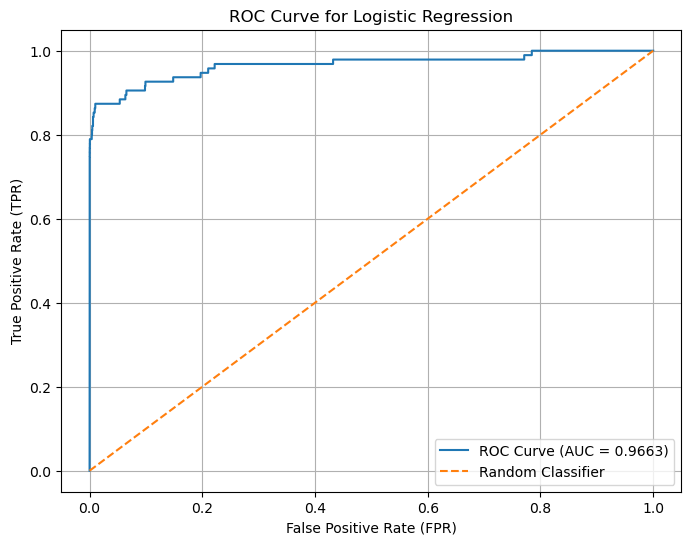

In [67]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Observation: 
- The ROC Curve lies significantly above the diagonal random-classifier line, and the model achieved an AUC of 96.63%.
- This indicates that the Logistic Regression model has an excellent ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.

#### REPORT

In [68]:
report=classification_report(y_test,y_pred)
print("Report:\n")
print(report)

Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



### Observation: 
- The Classification Report shows that the Logistic Regression model performs exceptionally well in identifying legitimate transactions, achieving a Precision of 1.00 and an F1-Score of 0.99.
- For fraudulent transactions, the model achieved a Recall of 0.87, indicating that it successfully detects most fraud cases.
- However, the Precision for the fraud class is only 0.05, meaning the model generates many false positive alerts.
- Overall, the model demonstrates excellent fraud detection capability but would benefit from threshold tuning or more advanced algorithms to improve Precision.

# Conclusion
- This project successfully developed a Credit Card Fraud Detection System using the Logistic Regression algorithm to identify fraudulent transactions from highly imbalanced credit card transaction data.
- The dataset was first explored and cleaned by checking for missing values, removing duplicate records, and performing exploratory data analysis to understand the distribution of legitimate and fraudulent transactions. Since the dataset was highly imbalanced, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data to improve the model's ability to learn fraud patterns.
- The features were standardized using StandardScaler, and the processed data was used to train a Logistic Regression model. The model was evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC-AUC Score, ROC Curve, and Classification Report.
- The model achieved:
   - Accuracy: 97.28%
   - Precision: 5.14%
   - Recall: 87.37%
   - F1-Score: 9.71%
   - ROC-AUC Score: 96.63%
- Although the Precision is relatively low due to the large number of false positive predictions, the model achieved a high Recall, successfully detecting most fraudulent transactions. This is particularly important in fraud detection because identifying fraudulent transactions is generally more critical than minimizing false alerts.
- Overall, the Logistic Regression model demonstrated strong classification capability, especially as indicated by its high ROC-AUC score, making it a solid baseline model for credit card fraud detection.

# Future Scope
- The performance of the fraud detection system can be further improved by:
   - Implementing advanced machine learning algorithms such as Random Forest, XGBoost, LightGBM, or CatBoost.
   - Performing hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
   - Optimizing the classification threshold to improve Precision while maintaining high Recall.
   - Applying additional feature engineering techniques to extract more informative features.
   - Deploying the trained model as a web application using Flask, FastAPI, or Streamlit for real-time fraud prediction.
   - Continuously retraining the model with newly available transaction data to improve its performance over time.